# Intro to Cell Reweighting

In [2]:
# Import packages
using Pkg
Pkg.activate("../..")  # Activate EnergyFlow.jl environment
using EnergyFlow
using UnROOT
using Plots
using LinearAlgebra
using Statistics
using ProgressMeter
using NPZ
using DelimitedFiles
using StatsBase

  Activating project at `~/Developer/2025/EnergyFlow.jl`
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2), incompatible header (2))


In [3]:
# Check number of CPU cores and threads
using Base.Threads
num_cores = Sys.CPU_THREADS
num_threads = Threads.nthreads()
println("Number of CPU cores: $num_cores")
println("Julia is running with $num_threads thread(s)")

if num_threads == 1 && num_cores > 1
    println("You're running with only 1 thread but have $num_cores cores available!")
    println("To enable multi-threading in Jupyter:")
    println("1. Close Jupyter")
    println("2. Set environment variable: export JULIA_NUM_THREADS=auto")
    println("3. Restart Jupyter: jupyter notebook")
end

Number of CPU cores: 12
Julia is running with 12 thread(s)


## Some Important Functions

In [4]:
# Function to transform coordinates from (E, px, py, pz) to (pT, eta, phi)
# Using EnergyFlow.jl's cartesian_to_hadronic function
function coord_transform(data)
    # EnergyFlow.jl expects (E, px, py, pz) format
    return EnergyFlow.cartesian_to_hadronic(data)
end

coord_transform (generic function with 1 method)

In [5]:
# Function for visualizing events
function event_plotting(status, event1, event2, hardprocess_EMD_etaphi, hardprocess_EMD_pt, 
                       showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
    if status == "Hard Process"
        scatter(hardprocess_EMD_etaphi[event1, :, 1], hardprocess_EMD_etaphi[event1, :, 2], 
                markersize = 2 * hardprocess_EMD_pt[event1, :], color = :blue, 
                label = "Event $event1", alpha=0.7)
        scatter!(hardprocess_EMD_etaphi[event2, :, 1], hardprocess_EMD_etaphi[event2, :, 2], 
                markersize = 2 * hardprocess_EMD_pt[event2, :], color = :red,
                label = "Event $event2", alpha=0.7)
        xlabel!("Rapidity")
        ylabel!("Azimuthal Angle")
        title!("Hard Process Particles for Events $event1 and $event2")
        xlims!(-5, 5)
        ylims!(-3.15, 3.15)

    elseif status == "Showered"
        scatter(showered_EMD_etaphi[event1, :, 1], showered_EMD_etaphi[event1, :, 2], 
                markersize = 2 * showered_EMD_pt[event1, :], color = :blue, 
                label = "Event $event1", alpha=0.7)
        scatter!(showered_EMD_etaphi[event2, :, 1], showered_EMD_etaphi[event2, :, 2], 
                markersize = 2 * showered_EMD_pt[event2, :], color = :red,
                label = "Event $event2", alpha=0.7)
        xlabel!("Rapidity")
        ylabel!("Azimuthal Angle")
        title!("Showered Particles for Events $event1 and $event2")
        xlims!(-5, 5)
        ylims!(-3.15, 3.15)

    elseif status == "Hadronized"
        scatter(hadronization_EMD_etaphi[event1, :, 1], hadronization_EMD_etaphi[event1, :, 2], 
                markersize = 2 * hadronization_EMD_pt[event1, :], color = :blue, 
                label = "Event $event1", alpha=0.7)
        scatter!(hadronization_EMD_etaphi[event2, :, 1], hadronization_EMD_etaphi[event2, :, 2], 
                markersize = 2 * hadronization_EMD_pt[event2, :], color = :red,
                label = "Event $event2", alpha=0.7)
        xlabel!("Rapidity")
        ylabel!("Azimuthal Angle")
        title!("Hadronized Particles for Events $event1 and $event2")
        xlims!(-5, 5)
        ylims!(-3.15, 3.15)
    end
end

event_plotting (generic function with 1 method)

# Preprocessing Data for EMD Calculation

In [6]:
# Read ROOT file of MC data - this contains all particle level and some event level info
file = ROOTFile("data/ppzjj_NLO_10k.root")
tree = LazyTree(file, "Events", ["Particle_energy", "Particle_px","Particle_py", "Particle_pz", 
                                 "Particle_status", "Particle_pid", "Particle_d1", "Particle_d2", "Particle_mass"])

# What data is actually in the file?
println("Available keys: ", keys(tree[1]))

Available keys: (:Particle_energy, :Particle_px, :Particle_d1, :Particle_status, :Particle_pz, :Particle_pid, :Particle_d2, :Particle_py, :Particle_mass)


In [7]:
# Define kinematic cut parameters
particle_y_cut = 4.9
particle_pt_cut = 0.1

# Number of events to analyze (total = 10k)
N = 10000

10000

In [8]:
# Let's look at the particle masses for event 1
println("Array of particle masses: ", tree[1].Particle_mass)

# How many particles are there? 
println("There are: ", length(tree[1].Particle_mass), " particles")

# Most massive particle?
println("Highest mass particle has mass: ", maximum(tree[1].Particle_mass), " GeV")

Array of particle masses: [0.0, 0.0, 0.0, 91.188, 0.33, 0.0, 0.33, 0.33, 91.188, 0.33, 0.33, 0.0, 0.33, 0.0, 0.0, 0.0, 91.188, 0.33, 0.33, 0.33, 0.0, 0.0, 0.0, 0.0, 91.188, 0.33, 0.33, 0.33, 0.0, 0.0, 0.0, 0.0, 91.188, 0.33, 0.33, 0.33, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33, 0.0, 0.0, 0.33, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33, 0.33, 0.0, 0.0, 0.0, 0.0, 0.93827, 0.0, 0.93827, 0.0, 0.57933, 91.188, 0.33, 0.33, 0.33, 0.0, 0.0, 0.0, 0.33, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33, 0.0, 1.5, 1.5, 1.5, 0.0, 1.5, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 0.33, 0.0, 0.0, 0.0, 0.0, 0.33, 0.757608022592434, 0.13957, 0.13957, 0.13498, 0.13957, 0.9812006468546072, 0.7787266682588515, 0.13957, 0.13957, 0.6836312511038029, 0.8015028176223338, 0.13498, 0.13957, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 2.00698, 0.7809358269709172, 1.18937, 1.18937, 0.687715843460687, 0.7850528848970512, 0.9062190163681499, 0.13957, 0.13957, 0.7735049654

### Print array of particle energies for event 500. How many particles are there in the event? What is the lowest energy?

In [9]:
# Exercise: Event 500 analysis
println("Array of particle energies for event 500: ", tree[500].Particle_energy)
println("Number of particles in event 500: ", length(tree[500].Particle_energy))
println("Lowest energy in event 500: ", minimum(tree[500].Particle_energy), " GeV")

Array of particle energies for event 500: [1.2871754669818074, 2.57386375368582, 5776.740669236249, 4753.594308058492, 102.5922366373943, 458.83919524308084, 463.002104764263, 378.13509684667537, 107.96609433522653, 4727.903820366089, 101.49324071707724, 462.52959243708324, 1.4998564728148267, 5776.740669235753, 4708.662960350755, 97.99889137063367, 392.2744737967658, 467.4036072849931, 109.32672915171813, 437.68084517293255, 34.1508276799499, 93.57082580285343, 256.12890395080433, 137.87627256078898, 107.59602643694933, 32.67838657878903, 74.95125830287847, 2.5402453089678807, 6500.0, 1.4998564728151678, 5996.832861480787, 399.31189485913535, 6500.0, 5776.740669237066, 4708.662960351826, 93.57082580287462, 256.12890395086225, 437.680845173032, 32.678386578796456, 2.5402453089682835, 34.15082767995766, 137.87627256082015, 74.9512583028955, 2634.4171722250517, 2074.245788127277, 1861.9099015832724, 239.34083067828246, 2607.4122280913057, 2293.772202383544, 322.65175399172875, 230.329102

In [10]:
# Which event has the most particles after applying kinematic cuts? This will set the size of kinematical array
max_particles = 0

@showprogress "Finding max particles..." for i in 1:N
    n_particles = length(tree[i].Particle_energy)
    if n_particles == 0
        continue
    end
    
    # Create four-momentum matrix
    four_momenta = zeros(n_particles, 4)
    four_momenta[:, 1] = tree[i].Particle_energy
    four_momenta[:, 2] = tree[i].Particle_px
    four_momenta[:, 3] = tree[i].Particle_py
    four_momenta[:, 4] = tree[i].Particle_pz
    
    # Apply cuts using EnergyFlow.jl
    cut_momenta = EnergyFlow.apply_kinematic_cuts(four_momenta, 
                                                  pT_min=particle_pt_cut, 
                                                  y_max=particle_y_cut, 
                                                  coords="cartesian")
    
    n_kept = size(cut_momenta, 1)
    if n_kept > max_particles
        global max_particles = n_kept
    end
end
        
println("Maximum particles after cuts: ", max_particles)

Finding max particles... 100%|███████████████████████████| Time: 0:00:01


Maximum particles after cuts: 1273


In [11]:
# Apply cuts and coordinate transformation to all events
main_coords = zeros(N, max_particles, 3) # array of all coordinates for all particles for N events
p_stat = 4 * ones(N, max_particles) # array of statuses of all particles for N events
main_pid = zeros(N, max_particles) # array of pids of all particles for N events
main_daughter1 = zeros(N, max_particles) # array of daughter 1s for all particles of N events
main_daughter2 = zeros(N, max_particles) # array of daughter 2s for all particles of N events

# Do cuts and coordinate transformation
@showprogress "Processing events..." for i in 1:N    
    n_particles = length(tree[i].Particle_energy)
    if n_particles == 0
        continue
    end
    
    # Create four-momentum matrix
    four_momenta = zeros(n_particles, 4)
    four_momenta[:, 1] = tree[i].Particle_energy
    four_momenta[:, 2] = tree[i].Particle_px
    four_momenta[:, 3] = tree[i].Particle_py
    four_momenta[:, 4] = tree[i].Particle_pz
    
    # Apply cuts using EnergyFlow.jl
    cut_momenta = EnergyFlow.apply_kinematic_cuts(four_momenta, 
                                                  pT_min=particle_pt_cut, 
                                                  y_max=particle_y_cut, 
                                                  coords="cartesian")
    
    n_kept = size(cut_momenta, 1)
    if n_kept > 0
        # Transform to hadronic coordinates using EnergyFlow.jl
        hadronic = EnergyFlow.cartesian_to_hadronic(cut_momenta)
        main_coords[i, 1:n_kept, :] = hadronic
        
        # Find which particles were kept by matching pT values
        kept_indices = Int[]
        for j in 1:n_particles
            pT = sqrt(four_momenta[j, 2]^2 + four_momenta[j, 3]^2)
            y = abs(atanh(four_momenta[j, 4] / four_momenta[j, 1]))
            if pT >= particle_pt_cut && y <= particle_y_cut
                push!(kept_indices, j)
            end
        end
        
        # Store particle properties
        if length(kept_indices) == n_kept  # Sanity check
            p_stat[i, 1:n_kept] = tree[i].Particle_status[kept_indices]
            main_pid[i, 1:n_kept] = tree[i].Particle_pid[kept_indices]
            main_daughter1[i, 1:n_kept] = tree[i].Particle_d1[kept_indices]
            main_daughter2[i, 1:n_kept] = tree[i].Particle_d2[kept_indices]
        end
    end
end

# Remove events that had all particles removed from cuts
zero_array = Int[]

for i in 1:N
    if all(main_coords[i, :, :] .== 0)
        push!(zero_array, i)
        println("Event $i has no particles after cuts")
    end
end

# Filter arrays to remove empty events
if !isempty(zero_array)
    keep_events = trues(N)
    keep_events[zero_array] .= false
    
    main_coords = main_coords[keep_events, :, :]
    p_stat = p_stat[keep_events, :]
    main_pid = main_pid[keep_events, :]
    main_daughter1 = main_daughter1[keep_events, :]
    main_daughter2 = main_daughter2[keep_events, :]
end

println("Removed ", length(zero_array), " empty events")

Processing events... 100%|███████████████████████████████| Time: 0:00:01


Removed 0 empty events


In [12]:
# pt and (eta,phi) arrays that are going to be used for the EMD calculation
EMD_pt = main_coords[:, :, 1]
EMD_etaphi = main_coords[:, :, 2:3]

10000×1273×2 Array{Float64, 3}:
[:, :, 1] =
 -1.96853     0.111441   -1.29143     …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
  3.29197     1.53593     1.40307        0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -1.06975    -2.51458    -0.00125167     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -3.44897    -0.20141    -1.72431        0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -0.660737    1.3579     -0.320929       0.0  0.0  0.0  0.0  0.0  0.0  0.0
  0.123258    0.0338831  -0.552805    …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -2.08595    -3.18815     0.686498       0.0  0.0  0.0  0.0  0.0  0.0  0.0
  2.61453     0.444823   -3.14249        0.0  0.0  0.0  0.0  0.0  0.0  0.0
  4.70791    -1.06691    -0.872359       0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -2.6516     -2.58723    -2.27895        0.0  0.0  0.0  0.0  0.0  0.0  0.0
  1.79229    -1.40204    -3.5488      …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -0.598092   -1.44835    -2.18011        0.0  0.0  0.0  0.0  0.0  0.0  0.0
 -1.11939     1.46931     1.87058        0.0  0.0  0.0  

In [13]:
# Separate particles by when they were produced: from hard process scattering, from parton shower, or from hadronization
N_filtered = size(main_coords, 1)

hadronization_EMD_pt = zeros(N_filtered, max_particles)
hardprocess_EMD_pt = zeros(N_filtered, max_particles)
showered_EMD_pt = zeros(N_filtered, max_particles)

hadronization_EMD_etaphi = zeros(N_filtered, max_particles, 2)
hardprocess_EMD_etaphi = zeros(N_filtered, max_particles, 2)
showered_EMD_etaphi = zeros(N_filtered, max_particles, 2)

# Track which events have no particles of each type
empty_hardprocess = Int[]
empty_showered = Int[]
empty_hadronization = Int[]

for i in 1:N_filtered
    # Find indices for hadronization particles (final state: both daughters == -1)
    fs_indices = findall((main_daughter1[i, :] .== -1) .& (main_daughter2[i, :] .== -1))
    if !isempty(fs_indices)
        temp_fs = length(fs_indices)
        hadronization_EMD_pt[i, 1:temp_fs] = EMD_pt[i, fs_indices]
        hadronization_EMD_etaphi[i, 1:temp_fs, :] = EMD_etaphi[i, fs_indices, :]
    else
        push!(empty_hadronization, i)
    end
    
    # Find indices for hard process particles (status == 23)
    sp_indices = findall(p_stat[i, :] .== 23)
    if !isempty(sp_indices)
        temp_sp = length(sp_indices)
        hardprocess_EMD_pt[i, 1:temp_sp] = EMD_pt[i, sp_indices]
        hardprocess_EMD_etaphi[i, 1:temp_sp, :] = EMD_etaphi[i, sp_indices, :]
    else
        push!(empty_hardprocess, i)
    end
    
    # Find indices for showered particles (70 < status < 80)
    sh_indices = findall((p_stat[i, :] .> 70) .& (p_stat[i, :] .< 80))
    if !isempty(sh_indices)
        temp_sh = length(sh_indices)
        showered_EMD_pt[i, 1:temp_sh] = EMD_pt[i, sh_indices]
        showered_EMD_etaphi[i, 1:temp_sh, :] = EMD_etaphi[i, sh_indices, :]
    else
        push!(empty_showered, i)
    end
end

println("Events with no hard process particles: $(length(empty_hardprocess))")
println("Events with no showered particles: $(length(empty_showered))")
println("Events with no hadronization particles: $(length(empty_hadronization))")

Events with no hard process particles: 1
Events with no showered particles: 0
Events with no hadronization particles: 0


In [14]:
# Remove excessive zeroes from pT, eta, phi arrays
max1 = max_particles
max2 = max_particles
max3 = max_particles

for i in 1:N_filtered
    A = count(hadronization_EMD_pt[i, :] .== 0)
    if A < max1
        global max1 = A
    end
    
    B = count(hardprocess_EMD_pt[i, :] .== 0)
    if B < max2
        global max2 = B
    end
        
    C = count(showered_EMD_pt[i, :] .== 0)
    if C < max3
        global max3 = C
    end
end

# Trim arrays to remove excessive zeros
hadronization_EMD_pt = hadronization_EMD_pt[:, 1:(max_particles - max1)]
hardprocess_EMD_pt = hardprocess_EMD_pt[:, 1:(max_particles - max2)]
showered_EMD_pt = showered_EMD_pt[:, 1:(max_particles - max3)]

hadronization_EMD_etaphi = hadronization_EMD_etaphi[:, 1:(max_particles - max1), :]
hardprocess_EMD_etaphi = hardprocess_EMD_etaphi[:, 1:(max_particles - max2), :]
showered_EMD_etaphi = showered_EMD_etaphi[:, 1:(max_particles - max3), :]

println("\nMax particles per type:")
println("Hard process: $(max_particles - max2)")
println("Showered: $(max_particles - max3)")
println("Hadronization: $(max_particles - max1)")

# Important note about empty events
if !isempty(empty_hardprocess)
    println("\n⚠️  Note: $(length(empty_hardprocess)) events have no hard process particles")
    println("These events will be handled specially during EMD calculation")


Max particles per type:
Hard process: 5
Showered: 95
Hadronization: 364


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///Users/harrywanghc/Developer/2025/EnergyFlow.jl/examples/emd/In[14]#40:77\[90mIn[14]:40:77[0;0m]8;;\
    println("\n⚠️  Note: $(length(empty_hardprocess)) events have no hard process particles")
    println("These events will be handled specially during EMD calculation")[48;2;120;70;70m[0;0m
[90m#                                                                           └ ── [0;0m[91mExpected `end`[0;0m

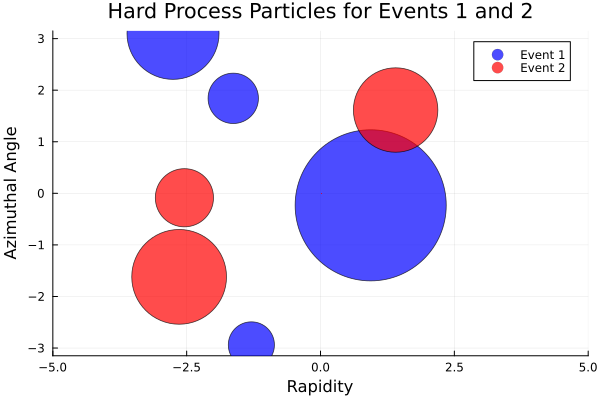

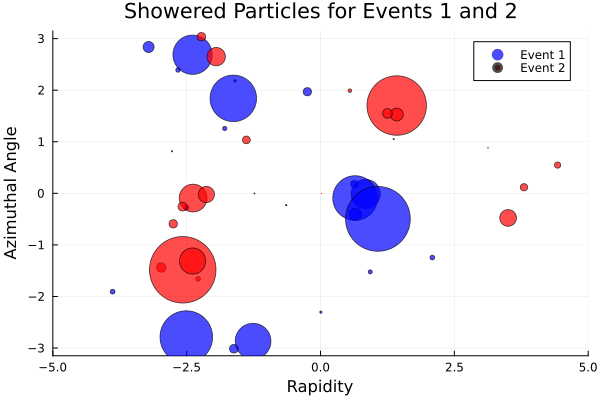

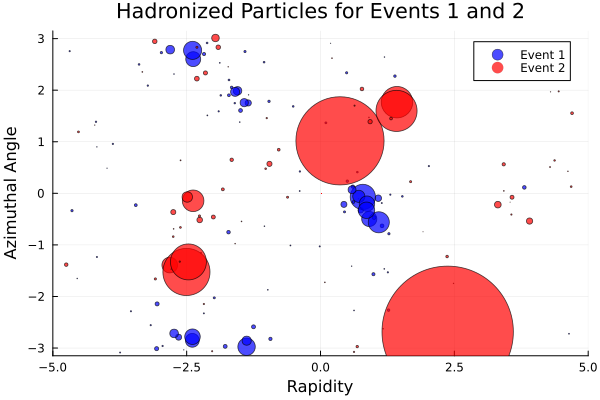

In [15]:
# How do these events look at each stage of the collision?
event1 = 1
event2 = 2

plot1 = event_plotting("Hard Process", event1, event2, hardprocess_EMD_etaphi, hardprocess_EMD_pt, 
                      showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
display(plot1)

plot2 = event_plotting("Showered", event1, event2, hardprocess_EMD_etaphi, hardprocess_EMD_pt, 
                      showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
display(plot2)

plot3 = event_plotting("Hadronized", event1, event2, hardprocess_EMD_etaphi, hardprocess_EMD_pt, 
                      showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
display(plot3)

### Play around with the event numbers in the plots. Can you find 2 events that look 'similar'? Or 'very different'?

In [16]:
# Now we need to get the weight for each event
# In the Python version, weights are read from a hepmc file
# Here we use a pre-extracted text file with the event weights

weights_file = "data/event_weights.txt"
event_weights = Float64[]

# Read the file line by line
open(weights_file, "r") do file
    for line in eachline(file)
        # Parse each line to extract the weight
        # Format: "event X weight: Y"
        if occursin("weight:", line)
            weight_str = split(line, "weight: ")[2]
            weight = parse(Float64, weight_str)
            push!(event_weights, weight)
        end
    end
end

# Filter to match the number of filtered events
if length(event_weights) > N_filtered
    event_weights = event_weights[1:N_filtered]
end

println("There are $(count(x -> x < 0, event_weights)) negative weighted events out of $(length(event_weights)) events")

There are 3699 negative weighted events out of 10000 events


In [17]:
# Total cross section (from generator)
weight = 1.455e4

# Dimensional weight per event
event_weights *= weight

10000-element Vector{Float64}:
 -86109.32403000002
 -86109.32403000002
  86109.32403000002
  86109.32403000002
 -86109.32403000002
  86109.32403000002
 -86109.32403000002
 -86109.32403000002
  86109.32403000002
 -86109.32403000002
  86109.32403000002
 -86109.32403000002
  86109.32403000002
      ⋮
  86109.32403000002
 -86109.32403000002
 -86109.32403000002
  86109.32403000002
  86109.32403000002
  86109.32403000002
 -86109.32403000002
  86109.32403000002
  86109.32403000002
  86109.32403000002
 -86109.32403000002
  86109.32403000002

In [18]:
# Make array of negative weighted events
neg_events = Int[]

for i in 1:length(event_weights)
    if event_weights[i] < 0
        push!(neg_events, i)
    end
end

println("Found $(length(neg_events)) negative weighted events")

Found 3699 negative weighted events


In [19]:
# Load array of 10M weights from big sample 
# We will use this later when plotting observables
big_event_weight = npzread("data/ppzjj_NLO_10M_weight.npy")

# Rescale 10k event weight to match 10M event weight to remove systematic bias
rescale = sum(big_event_weight) / sum(event_weights)
event_weights *= rescale

big_event_weight *= weight

if abs(1 - sum(big_event_weight) / sum(event_weights)) < 1e-5
    println("Rescaling done successfully")
end

# Computing the EMD - distance matrix and proximity matrix

There are 2 matrices I construct when doing the EMD. Distance matrix and proximity matrix have dimensions `N_negative × N_total`

Notice that these are not square matrices. I am only computing distances between negative events to all events - saves time and space

In [20]:
# Function to prepare events for EMD calculation
function prepare_events_for_emd(pt_array, etaphi_array, event_idx)
    # Get non-zero particles for this event
    mask = pt_array[event_idx, :] .> 0
    pt = pt_array[event_idx, mask]
    etaphi = etaphi_array[event_idx, mask, :]
    
    # Combine into the format expected by EnergyFlow (pT, y, phi)
    n_particles = length(pt)
    if n_particles == 0
        return zeros(0, 3)
    end
    
    event = zeros(n_particles, 3)
    event[:, 1] = pt
    event[:, 2:3] = etaphi
    
    return event
end

prepare_events_for_emd (generic function with 1 method)

In [21]:
# Use EnergyFlow.jl for EMD calculations
# Computing distance from negative events to all events for hard process particles

hardprocess_dist2neg = zeros(length(neg_events), N_filtered)

# Check which negative events have hard process particles
valid_neg_events = 0
for i in neg_events
    if !(i in empty_hardprocess)
        valid_neg_events += 1
    end
end
println("Valid negative events with hard process particles: $valid_neg_events out of $(length(neg_events))")

# Check if we have multiple threads available
using Base.Threads
if Threads.nthreads() > 1
    println("Computing EMD distances for hard process particles with $(Threads.nthreads()) threads...")
    
    # Create thread-safe progress tracking
    emd_progress_counter = Threads.Atomic{Int}(0)
    total_computations = length(neg_events)
    emd_progress = Progress(total_computations, desc="Hard process EMD...")
    
    # Parallel computation over negative events
    @threads for (i_idx, i) in collect(enumerate(neg_events))
        # Skip if this negative event has no hard process particles
        if i in empty_hardprocess
            hardprocess_dist2neg[i_idx, :] .= 1000.0  # Large distance for empty events
            Threads.atomic_add!(emd_progress_counter, 1)
            ProgressMeter.update!(emd_progress, emd_progress_counter[])
            continue
        end
        
        # Prepare event i for EMD
        event_i = prepare_events_for_emd(hardprocess_EMD_pt, hardprocess_EMD_etaphi, i)
        
        for j in 1:N_filtered
            # Skip if target event has no hard process particles
            if j in empty_hardprocess
                hardprocess_dist2neg[i_idx, j] = 1000.0
                continue
            end
            
            # Prepare event j for EMD
            event_j = prepare_events_for_emd(hardprocess_EMD_pt, hardprocess_EMD_etaphi, j)
            
            # Use EnergyFlow's emd function with same parameters as Python version
            try
                hardprocess_dist2neg[i_idx, j] = emd(event_i, event_j, 
                                                   R=1.0, 
                                                   beta=1.0, 
                                                   norm=false)
            catch e
                # This should rarely happen now that we're checking for empty events
                println("Thread $(Threads.threadid()): Unexpected error computing EMD between event $i and $j: $e")
                hardprocess_dist2neg[i_idx, j] = 1000.0
            end
        end
        
        Threads.atomic_add!(emd_progress_counter, 1)
        ProgressMeter.update!(emd_progress, emd_progress_counter[])
    end
else
    # Single-threaded version
    println("Computing EMD distances for hard process particles (single-threaded)...")
    println("💡 Tip: Run Jupyter with multiple threads for faster computation:")
    println("   export JULIA_NUM_THREADS=auto")
    println("   jupyter notebook")
    
    @showprogress "Hard process EMD..." for (i_idx, i) in enumerate(neg_events)
        # Skip if this negative event has no hard process particles
        if i in empty_hardprocess
            hardprocess_dist2neg[i_idx, :] .= 1000.0  # Large distance for empty events
            continue
        end
        
        # Prepare event i for EMD
        event_i = prepare_events_for_emd(hardprocess_EMD_pt, hardprocess_EMD_etaphi, i)
        
        for j in 1:N_filtered
            # Skip if target event has no hard process particles
            if j in empty_hardprocess
                hardprocess_dist2neg[i_idx, j] = 1000.0
                continue
            end
            
            # Prepare event j for EMD
            event_j = prepare_events_for_emd(hardprocess_EMD_pt, hardprocess_EMD_etaphi, j)
            
            # Use EnergyFlow's emd function with same parameters as Python version
            try
                hardprocess_dist2neg[i_idx, j] = emd(event_i, event_j, 
                                                   R=1.0, 
                                                   beta=1.0, 
                                                   norm=false)
            catch e
                # This should rarely happen now that we're checking for empty events
                println("Unexpected error computing EMD between event $i and $j: $e")
                hardprocess_dist2neg[i_idx, j] = 1000.0
            end
        end
    end
end

# Create proximity matrix (indices sorted by distance)
hardprocess_close2neg = zeros(Int, length(neg_events), N_filtered)

for i in 1:length(neg_events)
    hardprocess_close2neg[i, :] = sortperm(hardprocess_dist2neg[i, :])
end

# Remove self-distances (first column)
hardprocess_close2neg = hardprocess_close2neg[:, 2:end]

println("EMD computation completed!")

Valid negative events with hard process particles: 3698 out of 3699
Computing EMD distances for hard process particles with 12 threads...


Hard process EMD... 100%|████████████████████████████████| Time: 1:25:24


EMD computation completed!


In [22]:
# Load precomputed distance matrices for showered and hadronized particles
# (Computing these takes longer due to many more particles per event)
hadronization_dist2neg = readdlm("data/hadronization_dist2neg.csv", ',')
showered_dist2neg = readdlm("data/showered_dist2neg.csv", ',')

# Create proximity matrices
showered_close2neg = zeros(Int, length(neg_events), N_filtered)

for i in 1:length(neg_events)
    showered_close2neg[i, :] = sortperm(showered_dist2neg[i, :])
end

showered_close2neg = showered_close2neg[:, 2:end]

hadronization_close2neg = zeros(Int, length(neg_events), N_filtered)

for i in 1:length(neg_events)
    hadronization_close2neg[i, :] = sortperm(hadronization_dist2neg[i, :])
end

hadronization_close2neg = hadronization_close2neg[:, 2:end]

3699×9999 Matrix{Int64}:
 9997  6085  9356  9854  2722  4675  …  2460  3900  2950   670  8696    33
 2443  9762  7427  8265    13  2887     2460  2950  3900   670  8696    33
 7972   123   950  9159  2412   142     3900  2950  6490  8696   670    33
 4940  3643  4429  6860  6885  4184     2460  3900   670  2950  8696    33
 1533  4735  6416   684  8893  1503     2123  6599  8696  4138  5882    33
 4830  9532  4148  9363  1410  5703  …  4192  3952  8696  3916  5084  7178
 1147  8103  4528  1943  4110  2328     2460  2950  3900   670  8696    33
 5605  7928  2021  9673  7994  2690     6490  7292  2460   670  8696    33
 5537  2474  9698  5831  8411  8738     2950  3916  7178  5084  8696    33
 6959  2958  7644   827  2124  3589     2460  3900   670  2950  8696    33
 1178  4833  2802  3564  8825  5438  …  7493  2950  3900   670  8696    33
 2970  3701  7654  3178   894  5650     4138   670  7292  2460  8696    33
  555  8028  2830  1259  9791  8949     2460  3900  2950   670  8696    33


### Can you plot the 'most similar' and 'most dissimilar' events to the 10th negative event at all stages in the collision?

hint 1: event1 = neg_events[10] (this is the 10th negative event)

hint 2: you can find the most and least similar events using the proximity matrix


### Can you plot the global 'most dissimilar' events at each stage?

hint: use the distance matrix to find the max distance and then see what events have that distance between them (row and column)

10th negative event is event 21
Most similar hard process event: 265
Most dissimilar hard process event: 33


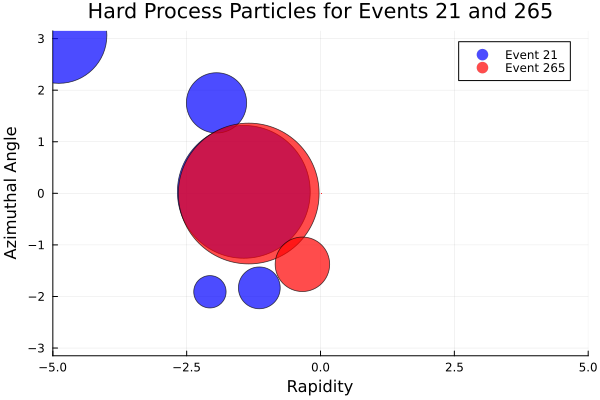

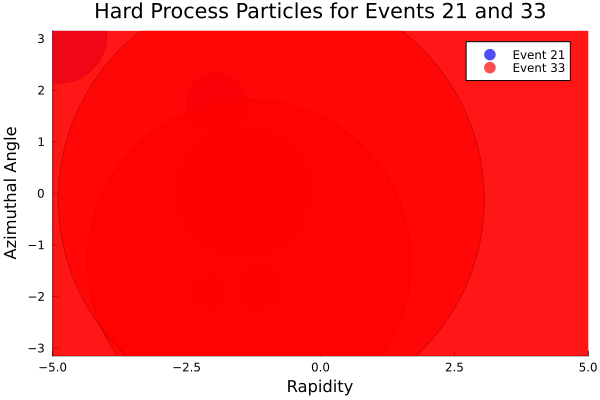

In [23]:
# Exercise: Plotting similar and dissimilar events
# Example: 10th negative event analysis
event1 = neg_events[10]

# Find most similar event (first in proximity matrix, excluding self)
most_similar_hard = Int(hardprocess_close2neg[10, 1])
# Find most dissimilar event (last in proximity matrix)
most_dissimilar_hard = Int(hardprocess_close2neg[10, end])

println("10th negative event is event $event1")
println("Most similar hard process event: $most_similar_hard")
println("Most dissimilar hard process event: $most_dissimilar_hard")

# Plot them
plot_similar = event_plotting("Hard Process", event1, most_similar_hard, hardprocess_EMD_etaphi, hardprocess_EMD_pt, 
                             showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
display(plot_similar)

plot_dissimilar = event_plotting("Hard Process", event1, most_dissimilar_hard, hardprocess_EMD_etaphi, hardprocess_EMD_pt,
                                showered_EMD_etaphi, showered_EMD_pt, hadronization_EMD_etaphi, hadronization_EMD_pt)
display(plot_dissimilar)

# Now let's do the reweighting

The order of reweighting is done from most to least isolated negative event. Which isolated event has the furthest nearest neighbor = most isolated event

Then cells are constructed with negative events as the seeds. If the total cell weight becomes positive and is smaller than the max radius, all events within it are reweighted. 

This process has to be done separately for hard process, showered, and hadronized particles

In [24]:
# Reshuffle distance and proximity matrices by most isolated negative events

# Find nearest neighbor distances for each negative event
hardprocess_nearest_neighbor = Float64[]
showered_nearest_neighbor = Float64[]
hadronization_nearest_neighbor = Float64[]

for i in 1:length(neg_events)
    # Find minimum non-zero distance
    push!(hardprocess_nearest_neighbor, minimum(filter(x -> x > 0, hardprocess_dist2neg[i, :])))
    push!(showered_nearest_neighbor, minimum(filter(x -> x > 0, showered_dist2neg[i, :])))
    push!(hadronization_nearest_neighbor, minimum(filter(x -> x > 0, hadronization_dist2neg[i, :])))
end

# Sort by most isolated (largest nearest neighbor distance)
hardprocess_isolation_order = sortperm(hardprocess_nearest_neighbor, rev=true)
showered_isolation_order = sortperm(showered_nearest_neighbor, rev=true)
hadronization_isolation_order = sortperm(hadronization_nearest_neighbor, rev=true)

# Reshuffle matrices
hardprocess_close2neg_reshuffled = hardprocess_close2neg[hardprocess_isolation_order, :]
hardprocess_dist2neg_reshuffled = hardprocess_dist2neg[hardprocess_isolation_order, :]
hardprocess_dist2neg_reshuffled = sort(hardprocess_dist2neg_reshuffled, dims=2)
hardprocess_dist2neg_reshuffled = hardprocess_dist2neg_reshuffled[:, 2:end]  # Remove self-distance

showered_close2neg_reshuffled = showered_close2neg[showered_isolation_order, :]
showered_dist2neg_reshuffled = showered_dist2neg[showered_isolation_order, :]
showered_dist2neg_reshuffled = sort(showered_dist2neg_reshuffled, dims=2)
showered_dist2neg_reshuffled = showered_dist2neg_reshuffled[:, 2:end]

hadronization_close2neg_reshuffled = hadronization_close2neg[hadronization_isolation_order, :]
hadronization_dist2neg_reshuffled = hadronization_dist2neg[hadronization_isolation_order, :]
hadronization_dist2neg_reshuffled = sort(hadronization_dist2neg_reshuffled, dims=2)
hadronization_dist2neg_reshuffled = hadronization_dist2neg_reshuffled[:, 2:end]

3699×9999 Matrix{Float64}:
 655.342   655.563   668.932   …  1752.5   1773.32  1800.02  1856.99
 646.551   667.175   698.061      1470.44  1478.75  1764.23  1873.46
 610.269   619.625   650.922      1687.02  1699.94  1752.02  1808.27
 531.425   533.088   546.777      1594.48  1610.4   1666.21  1682.95
 510.723   520.517   529.95       2351.88  2405.69  2444.3   2650.54
 480.982   494.948   503.688   …  1650.5   1652.49  1752.3   1842.1
 473.662   530.025   530.814      1635.53  1636.06  1672.19  1999.67
 470.043   472.793   479.057      1923.91  2038.07  2101.83  2244.98
 458.992   599.237   600.938      1665.82  1702.27  1717.98  1929.11
 454.909   494.23    514.998      1913.72  1958.61  1980.07  2003.84
 448.758   472.223   473.268   …  1606.56  1654.76  1670.71  1736.03
 418.967   428.17    475.1        1672.75  1682.16  1735.73  1763.84
 412.375   428.211   435.035      1420.44  1489.03  1511.47  1579.68
   ⋮                           ⋱     ⋮                       
  56.5146   56.

In [25]:
# Specify max cell radius
max_radius = 100.0

100.0

In [26]:
# Reweighting for hard process events
hardprocess_event_weight = copy(event_weights)
hardprocess_cell_radius = Float64[]

@showprogress "Reweighting hard process..." for i in 1:N_filtered
    if hardprocess_event_weight[i] < 0  # If the i-th event has negative weight
        cell_weight = hardprocess_event_weight[i]  # Cell weight = seed weight
        abs_cell_weight = abs(hardprocess_event_weight[i])  # Sum of absolute value of weights
        events_in_cell = [i]  # Index of events within cell
        
        # Find which negative event this is
        neg_idx = findfirst(x -> x == i, neg_events)
        if isnothing(neg_idx)
            continue
        end
        
        for j in 1:(N_filtered-1)  # Search through all events
            if cell_weight <= 0 && hardprocess_dist2neg_reshuffled[neg_idx, j] < max_radius
                # Add event to cell
                event_idx = Int(hardprocess_close2neg_reshuffled[neg_idx, j])
                
                cell_weight += hardprocess_event_weight[event_idx]
                abs_cell_weight += abs(hardprocess_event_weight[event_idx])
                push!(events_in_cell, event_idx)
            else
                break
            end
        end
        
        if cell_weight > 0
            push!(hardprocess_cell_radius, hardprocess_dist2neg_reshuffled[neg_idx, j-1])
            
            # Jeppe reweighting
            for event_idx in events_in_cell
                hardprocess_event_weight[event_idx] = cell_weight / abs_cell_weight * abs(hardprocess_event_weight[event_idx])
            end
        end
    end
end

LoadError: UndefVarError: `j` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
# Reweighting for showered events
showered_event_weight = copy(event_weights)
showered_cell_radius = Float64[]

@showprogress "Reweighting showered..." for i in 1:N_filtered
    if showered_event_weight[i] < 0
        cell_weight = showered_event_weight[i]
        abs_cell_weight = abs(showered_event_weight[i])
        events_in_cell = [i]
        
        neg_idx = findfirst(x -> x == i, neg_events)
        if isnothing(neg_idx)
            continue
        end
        
        for j in 1:(N_filtered-1)
            if cell_weight <= 0 && showered_dist2neg_reshuffled[neg_idx, j] < max_radius
                event_idx = Int(showered_close2neg_reshuffled[neg_idx, j])
                
                cell_weight += showered_event_weight[event_idx]
                abs_cell_weight += abs(showered_event_weight[event_idx])
                push!(events_in_cell, event_idx)
            else
                break
            end
        end
        
        if cell_weight > 0
            push!(showered_cell_radius, showered_dist2neg_reshuffled[neg_idx, j-1])
            
            for event_idx in events_in_cell
                showered_event_weight[event_idx] = cell_weight / abs_cell_weight * abs(showered_event_weight[event_idx])
            end
        end
    end
end

In [ ]:
# Reweighting for hadronized events
hadronization_event_weight = copy(event_weights)
hadronization_cell_radius = Float64[]

@showprogress "Reweighting hadronized..." for i in 1:N_filtered
    if hadronization_event_weight[i] < 0
        cell_weight = hadronization_event_weight[i]
        abs_cell_weight = abs(hadronization_event_weight[i])
        events_in_cell = [i]
        
        neg_idx = findfirst(x -> x == i, neg_events)
        if isnothing(neg_idx)
            continue
        end
        
        for j in 1:(N_filtered-1)
            if cell_weight <= 0 && hadronization_dist2neg_reshuffled[neg_idx, j] < max_radius
                event_idx = Int(hadronization_close2neg_reshuffled[neg_idx, j])
                
                cell_weight += hadronization_event_weight[event_idx]
                abs_cell_weight += abs(hadronization_event_weight[event_idx])
                push!(events_in_cell, event_idx)
            else
                break
            end
        end
        
        if cell_weight > 0
            push!(hadronization_cell_radius, hadronization_dist2neg_reshuffled[neg_idx, j-1])
            
            for event_idx in events_in_cell
                hadronization_event_weight[event_idx] = cell_weight / abs_cell_weight * abs(hadronization_event_weight[event_idx])
            end
        end
    end
end

In [ ]:
# Un-reshuffle the former negative weights after reweighting
# This is so that the event numbers in the weight arrays correspond to actual event numbers

# Create back-transformation indices
backtransform_hardprocess_idx = zeros(Int, length(hardprocess_isolation_order))
backtransform_hardprocess_idx[hardprocess_isolation_order] = 1:length(hardprocess_isolation_order)

backtransform_showered_idx = zeros(Int, length(showered_isolation_order))
backtransform_showered_idx[showered_isolation_order] = 1:length(showered_isolation_order)

backtransform_hadronization_idx = zeros(Int, length(hadronization_isolation_order))
backtransform_hadronization_idx[hadronization_isolation_order] = 1:length(hadronization_isolation_order)

# Apply back-transformation to negative event weights
hardprocess_event_weight[neg_events] = hardprocess_event_weight[neg_events][backtransform_hardprocess_idx]
showered_event_weight[neg_events] = showered_event_weight[neg_events][backtransform_showered_idx]
hadronization_event_weight[neg_events] = hadronization_event_weight[neg_events][backtransform_hadronization_idx]

In [ ]:
# What fraction of negative weights were reweighted?
println("$(1 - count(x -> x < 0, hardprocess_event_weight) / length(neg_events)) of negative weights are reweighted for hard process events at $max_radius GeV cell radius")
println("$(1 - count(x -> x < 0, showered_event_weight) / length(neg_events)) of negative weights are reweighted for showered events at $max_radius GeV cell radius")
println("$(1 - count(x -> x < 0, hadronization_event_weight) / length(neg_events)) of negative weights are reweighted for hadronized events at $max_radius GeV cell radius")

In [ ]:
# How big do cell radii typically get?
numbins = 20

# Hard Process
p1 = histogram(hardprocess_cell_radius, bins=numbins, 
               xlabel="Cell Radius (GeV)", 
               ylabel="Frequency",
               title="Histogram of Cell Radii (Hard Process)",
               legend=false)
display(p1)

# Showered
p2 = histogram(showered_cell_radius, bins=numbins,
               xlabel="Cell Radius (GeV)", 
               ylabel="Frequency",
               title="Histogram of Cell Radii (Showered)",
               legend=false)
display(p2)

# Hadronized
p3 = histogram(hadronization_cell_radius, bins=numbins,
               xlabel="Cell Radius (GeV)", 
               ylabel="Frequency",
               title="Histogram of Cell Radii (Hadronized)",
               legend=false)
display(p3)

### Mess around with different values of max_radius. See how the negative weight fraction and radius histograms change

# Now let's create some observables and see how the reweighting affects them
## (ignoring jet observables temporarily for the sake of time)

We also have to load data from 10M sample to compare to the 10k sample. All observables for this dataset are precomputed (it would take way too long otherwise).

In [ ]:
# 10k sample observables 

# HT (scalar sum of transverse momenta)
ht = zeros(N_filtered)
for i in 1:N_filtered
    ht[i] = sum(hadronization_EMD_pt[i, :])
end

# Z boson kinematics
# Find Z boson (status 22) and extract its properties
zpt = zeros(N_filtered)
zy = zeros(N_filtered)
zphi = zeros(N_filtered)

for i in 1:N_filtered
    # Find Z boson (status 22)
    z_idx = findall(tree[i].Particle_status .== 22)
    if !isempty(z_idx)
        # Get four-momentum of Z boson
        px = tree[i].Particle_px[z_idx[1]]
        py = tree[i].Particle_py[z_idx[1]]
        pz = tree[i].Particle_pz[z_idx[1]]
        E = tree[i].Particle_energy[z_idx[1]]
        
        # Calculate pT
        zpt[i] = sqrt(px^2 + py^2)
        
        # Calculate rapidity
        zy[i] = atanh(pz/E)
        
        # Calculate phi
        zphi[i] = atan(py, px)
    end
end

# zpt/ht
zpt_over_ht = zpt ./ ht

In [ ]:
# Load 10M data
big_ht = npzread("data/ppzjj_NLO_10M_ht.npy")
big_zcoords = npzread("data/ppzjj_NLO_10M_zcoords.npy")
big_zpt = big_zcoords[:, 1]
big_zy = big_zcoords[:, 2]
big_zphi = big_zcoords[:, 3]
big_zpt_over_ht = big_zpt ./ big_ht

## Plotting Module (using Julia Plots)

In [ ]:
# Function to create comparison plots with ratio panels
function create_comparison_plot(observable_10k, observable_10M, weights_10k, weights_10M,
                               hardreweight, showeredreweight, hadronreweight;
                               xlabel="Observable", numbins=50, logscale=false, 
                               logbins=false, minbin=10)
    
    # Determine bin edges
    min_val = minimum([minimum(observable_10k), minimum(observable_10M)])
    max_val = maximum([maximum(observable_10k), maximum(observable_10M)])
    
    if logbins
        bin_edges = 10 .^ range(log10(min_val - min_val/100), log10(max_val + max_val/100), length=numbins+1)
        # Prune bins that are too small
        pruned_bins = [bin_edges[1]]
        for b in bin_edges[2:end]
            if b - pruned_bins[end] >= minbin
                push!(pruned_bins, b)
            end
        end
        bin_edges = pruned_bins
    else
        bin_edges = range(min_val - min_val/100, max_val + max_val/100, length=numbins+1)
    end
    
    # Create histograms
    h_10M = fit(Histogram, observable_10M, Weights(weights_10M), bin_edges)
    h_orig = fit(Histogram, observable_10k, Weights(weights_10k), bin_edges)
    h_hard = fit(Histogram, observable_10k, Weights(hardreweight), bin_edges)
    h_shower = fit(Histogram, observable_10k, Weights(showeredreweight), bin_edges)
    h_hadron = fit(Histogram, observable_10k, Weights(hadronreweight), bin_edges)
    
    # Main plot
    p1 = plot(h_10M, label="10M Sample", linewidth=2, color=:magenta, 
              fillalpha=0, seriestype=:step, normalize=false)
    plot!(p1, h_orig, label="10k Sample", linewidth=2, color=:black, 
          fillalpha=0, seriestype=:step, normalize=false)
    plot!(p1, h_hard, label="Hard Process Reweight", linewidth=2, color=:red, 
          fillalpha=0, seriestype=:step, normalize=false)
    plot!(p1, h_shower, label="Showered Reweight", linewidth=2, color=:blue, 
          fillalpha=0, seriestype=:step, normalize=false)
    plot!(p1, h_hadron, label="Hadronization Reweight", linewidth=2, color=:green, 
          fillalpha=0, seriestype=:step, normalize=false)
    
    if logscale
        plot!(p1, yscale=:log10)
    end
    plot!(p1, xlabel="", ylabel="Frequency", legend=:topright, bottom_margin=0Plots.mm)
    
    # Ratio plot
    # Calculate ratios
    ratio_10M = h_10M.weights ./ h_10M.weights  # Always 1
    ratio_orig = h_orig.weights ./ h_10M.weights
    ratio_hard = h_hard.weights ./ h_10M.weights
    ratio_shower = h_shower.weights ./ h_10M.weights
    ratio_hadron = h_hadron.weights ./ h_10M.weights
    
    # Replace NaN/Inf with 1
    replace!(x -> isnan(x) || isinf(x) ? 1.0 : x, ratio_orig)
    replace!(x -> isnan(x) || isinf(x) ? 1.0 : x, ratio_hard)
    replace!(x -> isnan(x) || isinf(x) ? 1.0 : x, ratio_shower)
    replace!(x -> isnan(x) || isinf(x) ? 1.0 : x, ratio_hadron)
    
    # Get bin centers
    bin_centers = (bin_edges[1:end-1] + bin_edges[2:end]) / 2
    
    p2 = plot(bin_centers, ratio_10M, label="", linewidth=2, color=:magenta, 
              seriestype=:line, ylims=(0.5, 1.5))
    plot!(p2, bin_centers, ratio_orig, label="", linewidth=2, color=:black, seriestype=:line)
    plot!(p2, bin_centers, ratio_hard, label="", linewidth=2, color=:red, seriestype=:line)
    plot!(p2, bin_centers, ratio_shower, label="", linewidth=2, color=:blue, seriestype=:line)
    plot!(p2, bin_centers, ratio_hadron, label="", linewidth=2, color=:green, seriestype=:line)
    
    hline!(p2, [1.0], color=:gray, linestyle=:dash, label="")
    plot!(p2, xlabel=xlabel, ylabel="Ratio to 10M", legend=false, 
          top_margin=0Plots.mm, yticks=0.5:0.25:1.5)
    
    # Combine plots
    plot(p1, p2, layout=grid(2, 1, heights=[0.7, 0.3]), size=(800, 600))
end

In [ ]:
# Plot Z rapidity distribution
plot_zy = create_comparison_plot(zy, big_zy, event_weights, big_event_weight,
                                hardprocess_event_weight, showered_event_weight, hadronization_event_weight,
                                xlabel="Z Rapidity", numbins=50, logscale=false, logbins=false)
display(plot_zy)

In [ ]:
# Plot Z pT distribution
plot_zpt = create_comparison_plot(zpt, big_zpt, event_weights, big_event_weight,
                                 hardprocess_event_weight, showered_event_weight, hadronization_event_weight,
                                 xlabel="Z pT (GeV)", numbins=50, logscale=true, logbins=true, minbin=5)
display(plot_zpt)

In [ ]:
# Plot HT distribution
plot_ht = create_comparison_plot(ht, big_ht, event_weights, big_event_weight,
                                hardprocess_event_weight, showered_event_weight, hadronization_event_weight,
                                xlabel="HT (GeV)", numbins=50, logscale=false, logbins=false)
display(plot_ht)

### Mess with different parameters in the plotting module 

How does the bias change when you increase / decrease the number of bins?

What about log vs evenly sized bins?

Do some observables have more or less bias?

### Now go back and change the max cell radius and do the reweighting again and replot the observable with the new weights

How does the bias change when you increase / decrease the cell radius?

In [ ]:
# Note: This notebook uses EnergyFlow.jl functions for EMD calculations and kinematic cuts.
# Empty events (those with no particles of a specific type) are handled automatically.